In [3]:
import xgboost as xgb
from xgboost import plot_importance, plot_tree 
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [ ]:
df = pd.read_csv('Datasets/time_series.csv', index_col=[0], parse_dates=[0])

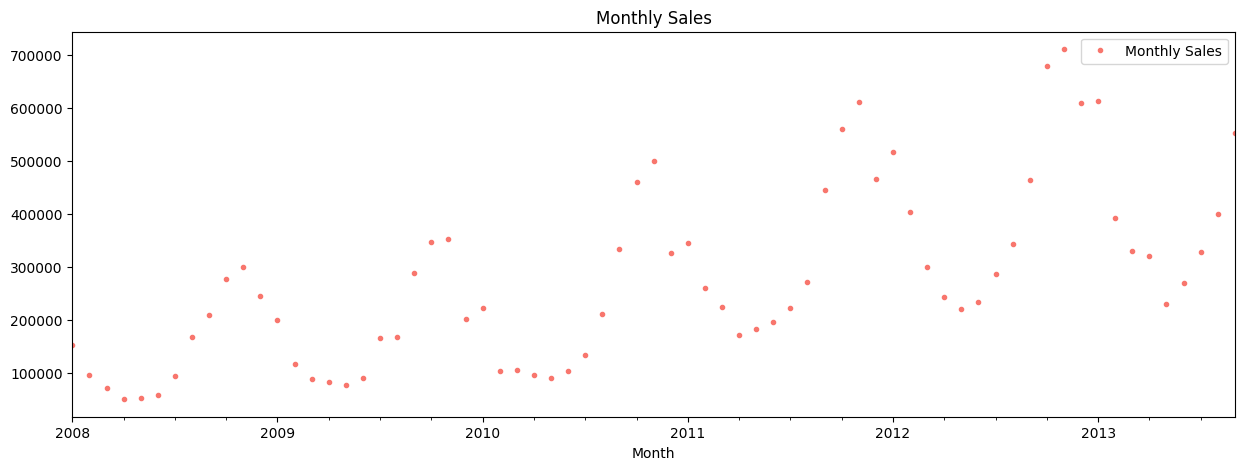

In [ ]:
color_pal = ["#F8766D", "#D39200", "#93AA00", "#00BA38", "#00C19F", "#00B9E3", "#619CFF", "#DB72FB"]
plot = df.plot(style='.', figsize=(15,5), color=color_pal[0], title='Monthly Sales')

In [ ]:
df.head(10)

,Monthly Sales
Month,
2008-01-01,154000
2008-02-01,96000
2008-03-01,73000
2008-04-01,51000
2008-05-01,53000
2008-06-01,59000
2008-07-01,95000
2008-08-01,169000
2008-09-01,210000


In [ ]:
split_date = '2011-01-01'
df_train = df.loc[df.index <= split_date].copy()
df_test = df.loc[df.index > split_date].copy()

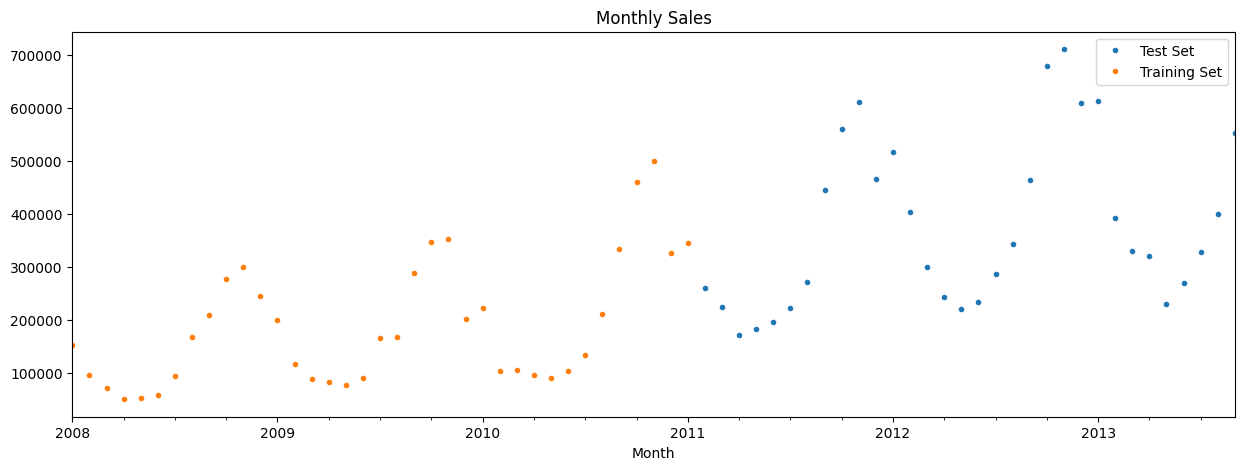

In [ ]:
plot1 = df_test \
    .rename(columns={'Monthly Sales': 'Test Set'}) \
    .join(df_train.rename(columns={'Monthly Sales': 'Training Set'}), how='outer') \
    .plot(figsize=(15,5), title='Monthly Sales', style='.')

In [ ]:
def create_features(df, label=None):
    """
    Creates time series features from datetime index
    """
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.weekofyear
    
    X = df[['hour','dayofweek','quarter','month','year',
           'dayofyear','dayofmonth','weekofyear']]
    if label:
        y = df[label]
        return X, y
    return X

In [ ]:
# creating training and test data for model
X_train, y_train = create_features(df_train, label='Monthly Sales')  # creates training data, adding additional features (columns)
X_test, y_test = create_features(df_test, label='Monthly Sales')     # creates test data, adding additional features (columns)

# create xgboost model 
model = xgb.XGBRegressor(n_estimators=1000)

# run the model 
model.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],   #evaluation set between X, y -train, test
        early_stopping_rounds=50,
       verbose=False) # Change verbose to True if you want to see it train

C:\Users\johnt\AppData\Local\Temp\ipykernel_1316\256030966.py:13: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  df['weekofyear'] = df['date'].dt.weekofyear
C:\Users\johnt\AppData\Local\Temp\ipykernel_1316\256030966.py:13: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  df['weekofyear'] = df['date'].dt.weekofyear
c:\Python\Python310\lib\site-packages\xgboost\sklearn.py:793: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=1000,
             n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
             reg_alpha=0, reg_lambda=1, ...)

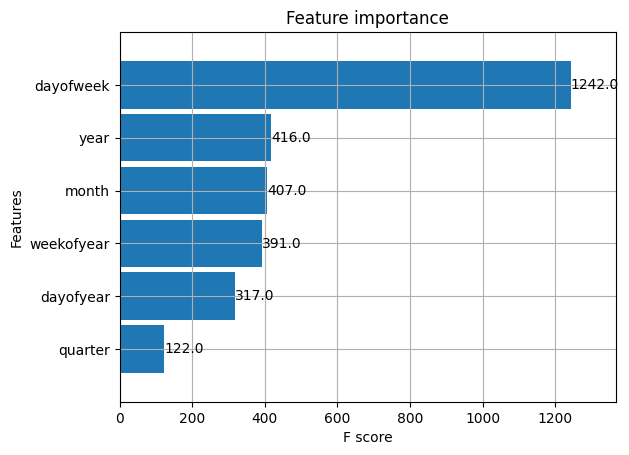

In [ ]:
# feature importance
plot2 = plot_importance(model, height=0.9)

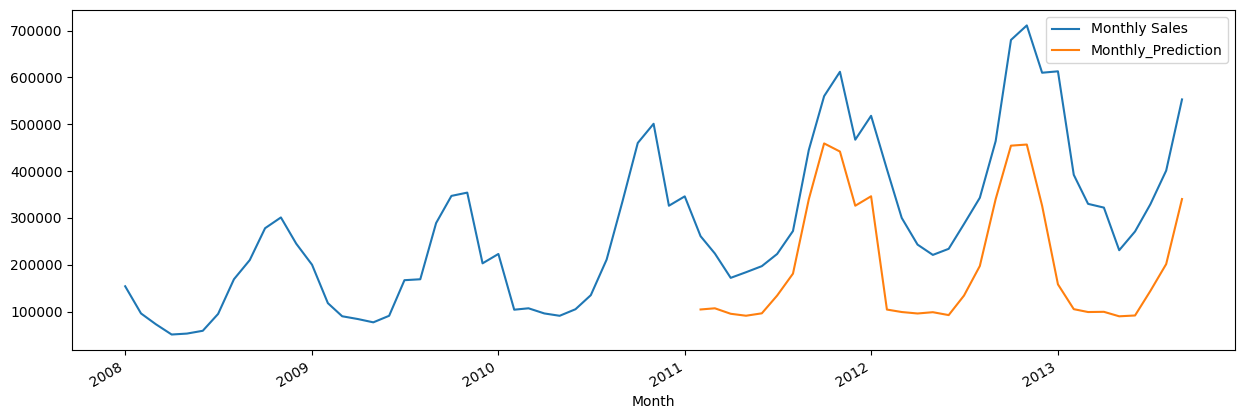

In [ ]:
# monthly sales vs. model prediction
df_test['Monthly_Prediction'] = model.predict(X_test)
df_all = pd.concat([df_test, df_train], sort=False)
plot3 = df_all[['Monthly Sales','Monthly_Prediction']].plot(figsize=(15, 5))

In [ ]:
# setting index to make it easier to plot
df_all.set_index(['Monthly Sales', 'Monthly_Prediction'])

,,date,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Monthly Sales,Monthly_Prediction,,,,,,,,,
261000,104483.742188,2011-02-01,0,1,1,2,2011,32,1,5
224000,106995.164062,2011-03-01,0,1,1,3,2011,60,1,9
172000,95296.757812,2011-04-01,0,4,2,4,2011,91,1,13
184000,91118.484375,2011-05-01,0,6,2,5,2011,121,1,17
197000,96260.671875,2011-06-01,0,2,2,6,2011,152,1,22
...,...,...,...,...,...,...,...,...,...,...
335000,NaN,2010-09-01,0,2,3,9,2010,244,1,35
460000,NaN,2010-10-01,0,4,4,10,2010,274,1,39
501000,NaN,2010-11-01,0,0,4,11,2010,305,1,44


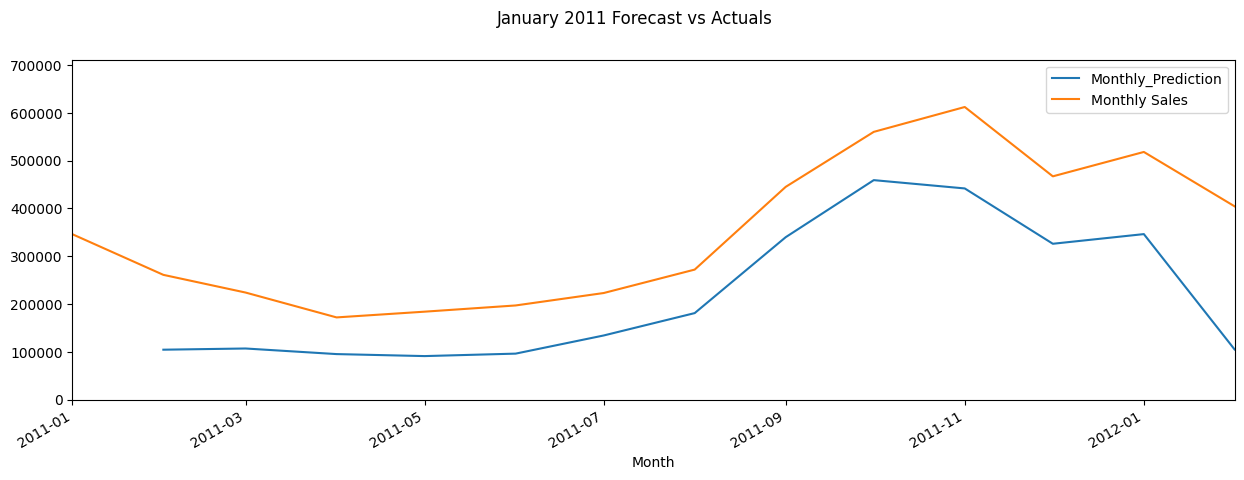

In [ ]:
# Plot the forecast with the actuals
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
_ = df_all[['Monthly_Prediction','Monthly Sales']].plot(ax=ax,
                                              style=['-','-'])
ax.set_xbound(lower='01-01-2011', upper='02-01-2012')
ax.set_ylim(0, 711000)
plot4 = plt.suptitle('January 2011 Forecast vs Actuals')

In [ ]:
# model performance
from sklearn.metrics import mean_squared_error, mean_absolute_error
# mean squared error
mean_squared_error(y_true=df_test['Monthly Sales'],
                   y_pred=df_test['Monthly_Prediction'])

37038585332.98276

In [ ]:
# mean absolute error
def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true))

mean_absolute_percentage_error(y_true=df_test['Monthly Sales'],
                   y_pred=df_test['Monthly_Prediction'])

0.4932104912782666

In [ ]:
mape = mean_absolute_percentage_error(df_test['Monthly Sales'], df_test['Monthly_Prediction'])
mape

0.4932104912782666